# Attribute interoperability between Higra and `mmcfilters`

This notebook builds a max-tree with Higra, imports the hierarchy into `mmcfilters`, computes one selected attribute in the preserved Higra node-ID space, and reuses those values in a Higra reconstruction.

## Goal

Demonstrate an attribute-independent interoperability pattern. `SELECTED_ATTRIBUTE` may be replaced by any single attribute compatible with the imported hierarchy's capabilities. The filtering predicate and threshold remain method-specific choices; they are not implied by attribute projection.

## Setup

Higra remains responsible for hierarchy construction and image reconstruction. `mmcfilters` provides attribute computation and projection into the original Higra layout.

In [1]:
import mmcfilters
from pathlib import Path

import cv2 as cv
import higra as hg
import matplotlib.pyplot as plt
import numpy as np


def load_grayscale(path):
    image = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return np.ascontiguousarray(image, dtype=np.uint8)


def show_images(images, *, figsize=(16, 5), vmin=0, vmax=255):
    figure, axes = plt.subplots(1, len(images), figsize=figsize, constrained_layout=True)
    if len(images) == 1:
        axes = [axes]
    for axis, (title, image) in zip(axes, images):
        axis.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        axis.set_title(title)
        axis.axis("off")
    plt.show()

## Select an attribute

Only this cell determines the attribute used below. 

The quantile defines the demonstration threshold over internal-node values. Change the removal rule when the selected attribute requires different semantics.

In [2]:
SELECTED_ATTRIBUTE = mmcfilters.Attribute.MAX_DIST
REMOVAL_QUANTILE = 0.95

attribute_label = SELECTED_ATTRIBUTE.name
print(f"Selected attribute: {attribute_label}")

Selected attribute: MAX_DIST


## Load the input image

image shape: (871, 518), dtype: uint8


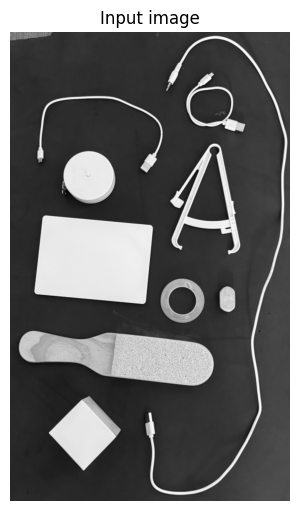

In [3]:
image_path = Path("../dat/imgObjetos.png")
input_image = load_grayscale(image_path)
rows, columns = input_image.shape

print(f"image shape: {input_image.shape}, dtype: {input_image.dtype}")
show_images([("Input image", input_image)])

## Build the max-tree with Higra

`hg.get_8_adjacency_graph` uses the 8-neighborhood on the image grid. This corresponds to the `mmcfilters` radius `1.5` used when the hierarchy is imported.

In [4]:
higra_graph = hg.get_8_adjacency_graph(input_image.shape)
higra_tree, higra_altitude = hg.component_tree_max_tree(
    higra_graph,
    input_image.ravel(),
)

higra_parent = np.asarray(higra_tree.parents(), dtype=np.int32)
higra_altitude = np.asarray(higra_altitude, dtype=np.uint8)

print(f"Higra vertices: {higra_tree.num_vertices()}")
print(f"Higra leaves:   {higra_tree.num_leaves()}")
print(f"Higra root:     {higra_tree.root()}")

Higra vertices: 477033
Higra leaves:   451178
Higra root:     477032


## Import the hierarchy into `mmcfilters`

`createFromHigraParent` preserves the imported Higra node-ID domain until the topology is edited. Requesting `NodeIdSpace.HIGRA` later returns attribute rows aligned with `higra_parent` and `higra_altitude`.

In [5]:
valued_tree = mmcfilters.MorphologicalTreeFactory.create_from_higra_parent(
    higra_parent.tolist(),
    higra_altitude.tolist(),
    rows,
    columns,
    mmcfilters.MorphologicalTreeKind.MAX_TREE,
    radius=1.5,
)

assert np.array_equal(valued_tree.reconstruct_from_node_altitudes(), input_image)
assert valued_tree.num_higra_nodes == higra_tree.num_vertices()

print(f"mmcfilters internal node slots: {valued_tree.num_internal_node_slots}")
print("round-trip reconstruction matches the input image")

mmcfilters internal node slots: 25855
round-trip reconstruction matches the input image


## Compute the selected attribute in Higra space

Attribute computation runs in the internal morphological-tree domain and is projected at the API boundary. Proper-part leaf rows receive the registered unit-component value for the selected attribute; the notebook does not patch those rows manually.

In [6]:
attribute_by_higra = np.asarray(
    mmcfilters.Attribute.compute_single_attribute(
        valued_tree,
        SELECTED_ATTRIBUTE,
        output_space=mmcfilters.NodeIdSpace.HIGRA,
    ),
    dtype=np.float64,
)

num_leaves = higra_tree.num_leaves()
internal_attribute = attribute_by_higra[num_leaves:]
finite_internal_attribute = internal_attribute[np.isfinite(internal_attribute)]

assert attribute_by_higra.shape == (higra_tree.num_vertices(),)
if finite_internal_attribute.size == 0:
    raise ValueError(f"{attribute_label} has no finite internal-node value.")

print(f"{attribute_label} shape: {attribute_by_higra.shape}")
print(
    f"finite internal range: {finite_internal_attribute.min():.3g} "
    f"to {finite_internal_attribute.max():.3g}"
)

MAX_DIST shape: (477033,)
finite internal range: 0 to 6.66e+04


## Apply an explicit Higra removal rule

For this demonstration, internal nodes below a selected quantile are removed. Leaves and the root are always preserved. This rule is appropriate for increasing attributes such as `AREA`; choose a scientifically justified predicate for other attributes.

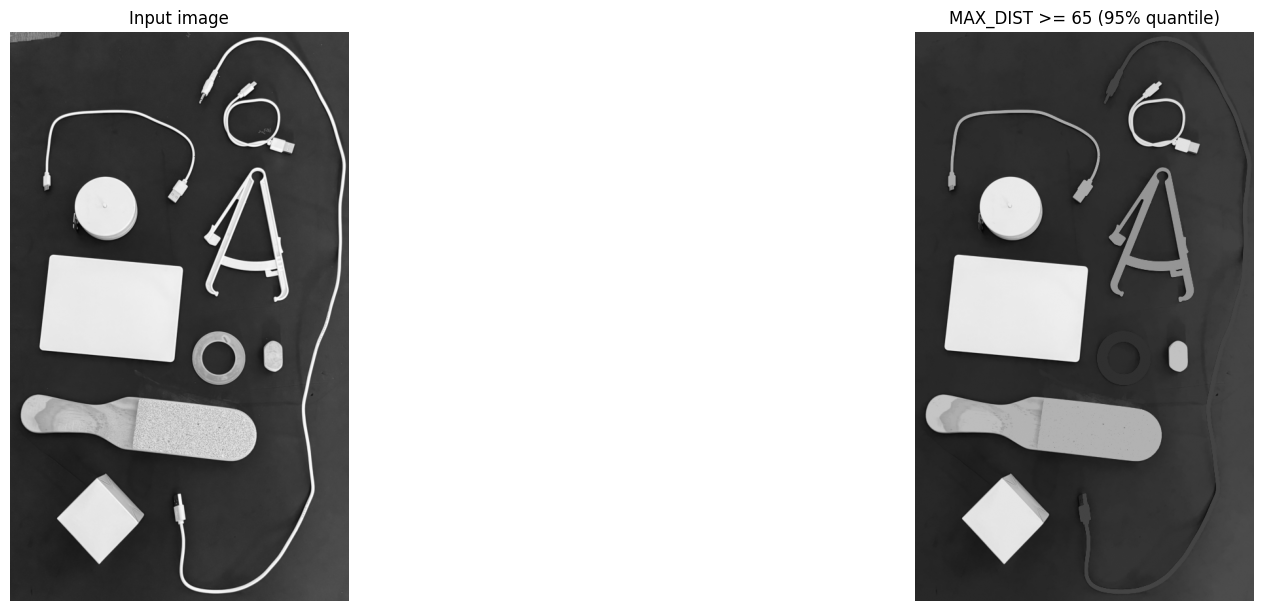

In [7]:
attribute_threshold = float(
    np.quantile(finite_internal_attribute, REMOVAL_QUANTILE)
)

nodes_to_delete = np.zeros(higra_tree.num_vertices(), dtype=bool)
nodes_to_delete[num_leaves:] = internal_attribute < attribute_threshold
nodes_to_delete[higra_tree.root()] = False

attribute_filtered_image = hg.reconstruct_leaf_data(
    higra_tree,
    higra_altitude,
    nodes_to_delete,
).reshape(input_image.shape)

show_images(
    [
        ("Input image", input_image),
        (
            f"{attribute_label} >= {attribute_threshold:.3g} "
            f"({REMOVAL_QUANTILE:.0%} quantile)",
            attribute_filtered_image,
        ),
    ],
    figsize=(18, 6),
)

## Checks

In [8]:
assert np.array_equal(valued_tree.reconstruct_from_node_altitudes(), input_image)
assert attribute_by_higra.shape == higra_parent.shape
assert np.isfinite(attribute_by_higra).all()
assert not nodes_to_delete[:num_leaves].any()
assert not nodes_to_delete[higra_tree.root()]
assert attribute_filtered_image.shape == input_image.shape

print(
    f"Projected {attribute_label} to {attribute_by_higra.size} Higra vertices; "
    f"removed {nodes_to_delete.sum()} internal nodes."
)

Projected MAX_DIST to 477033 Higra vertices; removed 24520 internal nodes.


## Interpretation

Changing `SELECTED_ATTRIBUTE` changes the computation while preserving the interoperability path. `NodeIdSpace.HIGRA` is the key contract: it aligns internal `mmcfilters` results with the original imported Higra hierarchy and supplies the correct unit values for proper-part leaves. Attribute compatibility and the removal predicate must still be evaluated separately.